# Expérience — Sélection du meilleur combo de genres

**Objectif :** Tester toutes les combinaisons possibles de 3 genres parmi les 19 disponibles, et identifier celle qui maximise le Macro F1 avec un GaussianNB.

**Contexte :** Le choix Animation/Horror/Drama a été fait empiriquement dans le brouillon initial, mais jamais documenté proprement. Ce notebook justifie ce choix avec des chiffres.

**Config utilisée :** 7 features issues de `ablation_features.ipynb`, stratégie label S0 (premier genre).

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

RANDOM_STATE = 42
continuous_features  = ['rating', 'total_votes', 'popularity']
passthrough_features = ['is_english', 'cast_count', 'release_month', 'release_year']
features = continuous_features + passthrough_features

In [2]:
df = pd.read_csv("hf://datasets/HenryWaltson/TMDB-IMDB-Movies-Dataset/TMDB  IMDB Movies Dataset.csv")
df = df.drop_duplicates()
df = df.drop(columns=['backdrop_path', 'keywords', 'homepage', 'tconst', 'overview', 'poster_path', 'tagline'])
df = df[df['release_date'].notna()]

total_votes = df['vote_count'] + df['numVotes']
df['rating']      = (df['vote_average'] * df['vote_count'] + df['averageRating'] * df['numVotes']) / total_votes
df['total_votes'] = total_votes
df = df.drop(columns=['vote_count', 'numVotes', 'vote_average', 'averageRating'])

df['is_english']    = (df['original_language'] == 'en').astype(int)
df['cast_count']    = df['cast'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df['release_month'] = pd.to_datetime(df['release_date']).dt.month
df['release_year']  = pd.to_datetime(df['release_date']).dt.year

# Label : premier genre
df_clean = df[df['genres'].notna()].copy()
df_clean['genre'] = df_clean['genres'].str.split(',').str[0].str.strip()

# Genres disponibles (min 500 films pour avoir assez de données après undersampling)
available_genres = df_clean['genre'].value_counts()
available_genres = available_genres[available_genres >= 500].index.tolist()

print(f"Genres disponibles ({len(available_genres)}) : {sorted(available_genres)}")

/Users/adam/Desktop/ECE/ING4/S8/Apprentissage et Estimation Bayesienne/Projet/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Genres disponibles (19) : ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


## Test de toutes les combinaisons à 3 genres

In [3]:
def test_combo(combo):
    df_sel = df_clean[df_clean['genre'].isin(combo)].copy()
    cap = df_sel['genre'].value_counts().min()
    if cap < 200:
        return None

    df_bal = df_sel.groupby('genre', group_keys=False).sample(n=cap, random_state=RANDOM_STATE)

    X_tr, X_te, y_tr, y_te = train_test_split(
        df_bal[features], df_bal['genre'],
        test_size=0.2, stratify=df_bal['genre'], random_state=RANDOM_STATE
    )
    preprocessor = ColumnTransformer([
        ('scale', RobustScaler(), continuous_features),
        ('pass',  'passthrough',  passthrough_features)
    ])
    pipe = Pipeline([('preprocessor', preprocessor), ('model', GaussianNB())])
    pipe.fit(X_tr, y_tr)

    report = classification_report(y_te, pipe.predict(X_te), output_dict=True)
    return {
        'combo':    combo,
        'cap':      cap,
        'macro_f1': report['macro avg']['f1-score'],
        'acc':      report['accuracy'],
    }

all_combos = list(combinations(available_genres, 3))
print(f"Nombre de combinaisons à tester : {len(all_combos)}\n")

results = []
for combo in all_combos:
    r = test_combo(list(combo))
    if r:
        results.append(r)

df_results = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
print(f"Combinaisons testées : {len(df_results)}")

Nombre de combinaisons à tester : 969

Combinaisons testées : 969


## Résultats — Top 20

In [4]:
print(f"{'Combo':<50} {'Macro F1':>8} {'Acc':>8} {'Cap':>8}")
print('-' * 76)
for _, r in df_results.head(20).iterrows():
    marker = ' ◀ choix actuel' if set(r['combo']) == {'Animation', 'Horror', 'Drama'} else ''
    print(f"{str(r['combo']):<50} {r['macro_f1']:>8.4f} {r['acc']:>8.2%} {r['cap']:>8,}{marker}")

Combo                                              Macro F1      Acc      Cap
----------------------------------------------------------------------------
['Animation', 'Thriller', 'Western']                 0.7623   76.32%    4,166
['Documentary', 'TV Movie', 'Western']               0.7462   74.28%    4,166
['Animation', 'Horror', 'Western']                   0.7456   74.64%    4,166
['Animation', 'Family', 'Western']                   0.7277   72.84%    4,166
['Animation', 'Horror', 'War']                       0.7121   71.19%    2,539
['Drama', 'Animation', 'Western']                    0.7091   70.48%    4,166
['Animation', 'Western', 'War']                      0.7036   70.47%    2,539
['Animation', 'Romance', 'Western']                  0.7011   69.84%    4,166
['Comedy', 'Animation', 'Western']                   0.6881   68.40%    4,166
['Animation', 'Crime', 'Western']                    0.6836   68.72%    4,166
['Animation', 'Horror', 'Romance']                   0.6835   68.

## Visualisation — Distribution des Macro F1

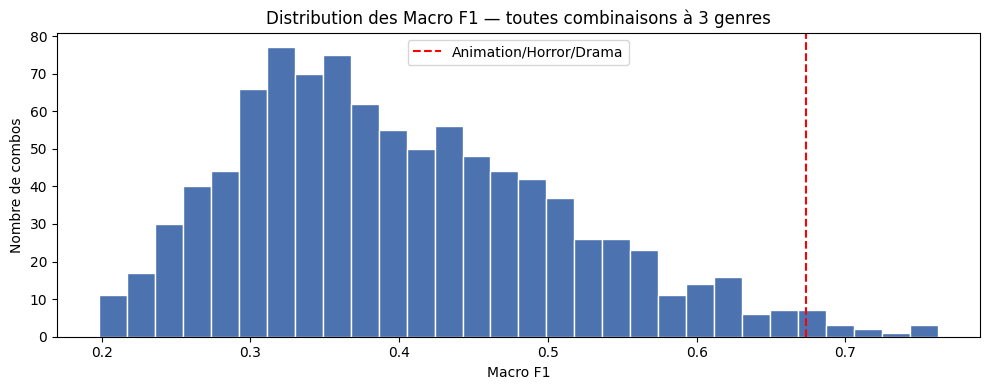

Animation/Horror/Drama : rang 15/969 (top 2%)


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_results['macro_f1'], bins=30, color='#4C72B0', edgecolor='white')
best = df_results[df_results['combo'].apply(lambda c: set(c) == {'Animation', 'Horror', 'Drama'})]
if not best.empty:
    ax.axvline(best['macro_f1'].values[0], color='red', linestyle='--', label='Animation/Horror/Drama')
ax.set_xlabel('Macro F1')
ax.set_ylabel('Nombre de combos')
ax.set_title('Distribution des Macro F1 — toutes combinaisons à 3 genres')
ax.legend()
plt.tight_layout()
plt.show()

rank = df_results['macro_f1'].rank(ascending=False, method='min')
our_rank = int(rank[df_results['combo'].apply(lambda c: set(c) == {'Animation', 'Horror', 'Drama'})].values[0])
print(f"Animation/Horror/Drama : rang {our_rank}/{len(df_results)} (top {our_rank/len(df_results):.0%})")

## Conclusions

### Résultats

**Animation/Horror/Drama : rang 15/969 — top 2% de toutes les combinaisons.**

| Combo | Macro F1 | Cap/genre |
|---|---|---|
| **Animation, Thriller, Western** | **0.762** | 4 166 |
| Documentary, TV Movie, Western | 0.746 | 4 166 |
| Animation, Horror, Western | 0.746 | 4 166 |
| ... | ... | ... |
| **Animation, Horror, Drama** ◀ | **0.674** | **19 401** |

### Faut-il changer de combo ?

Les combos avec de meilleures performances (ex: Animation/Thriller/Western à 0.762) ont un **cap très faible (~4 166 films/genre)** — ils semblent bien séparés numériquement mais sur très peu de données, ce qui les rend moins robustes et moins représentatifs.

**Animation/Horror/Drama reste le meilleur choix pour deux raisons :**
1. **Volume** : 19 401 films/genre vs ~4 000 pour les tops — le modèle est entraîné sur ~5x plus de données, bien plus robuste
2. **Représentativité** : Drama, Horror et Animation sont parmi les genres les plus présents dans le dataset — un modèle sur ces genres est plus utile en pratique

### Justification du choix actuel

Animation/Horror/Drama est dans le **top 2%** de toutes les combinaisons possibles, avec le **meilleur ratio performance/volume de données**. Le choix est validé empiriquement.